# Human Activity Recognition — Feature Engineering

Notebook 1 of 2 · [02_classification.ipynb](./02_classification.ipynb)

Extract time-domain statistical features from the UCI AReM wireless RSS dataset,
estimate feature stability via bootstrap confidence intervals, and identify the
three most discriminative features by between-class variance.

**Dataset:** UCI AReM — 7 activities, 6 RSS time series per instance  
**Key output:** 42-feature matrix (7 stats × 6 series) ready for classification


## 1. Load data


### 1(a) Load libraries and download AReM dataset

In [1]:
# Setup and import libraries
import os
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download the AReM dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00366/AReM.zip'
data_dir = '../data'
zip_path = os.path.join(data_dir, 'AReM.zip')

urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(data_dir)
# List activity folders
activities = sorted(os.listdir(data_dir))
activities = [a for a in activities if os.path.isdir(os.path.join(data_dir, a))]
print("folders:", activities)

folders: ['bending1', 'bending2', 'cycling', 'lying', 'sitting', 'standing', 'walking']


### 1(b) Train/Test Split

In [2]:
def load_activity_files(activity_path):
    """Load all CSV files from an activity folder, return list of DataFrames."""
    files = sorted([
        f for f in os.listdir(activity_path)
        if f.endswith('.csv') or f.endswith('.txt')
    ])
    return files

def parse_file(filepath):
    """Parse a single AReM data file into a DataFrame with 6 time series columns."""
    try:
        df = pd.read_csv(
            filepath,
            comment='#',
            header=None,
            sep=',',
            engine='python',
            skip_blank_lines=True
        )
        # Drop any extra columns, keep first 6
        df = df.iloc[:, :6]
        df.columns = ['avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23']
        df = df.apply(pd.to_numeric, errors='coerce').dropna()
        return df
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

# Define train/test split
# bending1, bending2: datasets 1,2 are TEST; rest are TRAIN
# other folders: datasets 1,2,3 are TEST; rest are TRAIN
bending_folders = ['bending1', 'bending2']
other_folders = [a for a in activities if a not in bending_folders]

train_data = []  # list of (DataFrame, label)
test_data  = []  # list of (DataFrame, label)

for activity in activities:
    act_path = os.path.join(data_dir, activity)
    files = load_activity_files(act_path)
    
    if activity in bending_folders:
        test_indices  = [0, 1]          # dataset 1, 2 → test
        train_indices = list(range(2, len(files)))
    else:
        test_indices  = [0, 1, 2]       # dataset 1, 2, 3 → test
        train_indices = list(range(3, len(files)))
    
    for idx in test_indices:
        if idx < len(files):
            df = parse_file(os.path.join(act_path, files[idx]))
            if df is not None:
                test_data.append((df, activity))
    
    for idx in train_indices:
        if idx < len(files):
            df = parse_file(os.path.join(act_path, files[idx]))
            if df is not None:
                train_data.append((df, activity))

print(f"Training instances: {len(train_data)}")
print(f"Test instances:     {len(test_data)}")

Error reading ../data/bending2/dataset4.csv: Length mismatch: Expected axis has 1 elements, new values have 6 elements
Error reading ../data/cycling/dataset14.csv: Expected 7 fields in line 485, saw 8
Error reading ../data/cycling/dataset9.csv: Expected 7 fields in line 485, saw 8
Training instances: 66
Test instances:     19


### 1(c) Feature Extraction

#### 1(c)(i) Time-Domain Features Commonly Used in Time Series Classification

Common time-domain features used in time series classification include:

| Feature | Description |
|---|---|
| **Minimum** | Smallest value in the series |
| **Maximum** | Largest value in the series |
| **Mean** | Average value |
| **Median** | Middle value (50th percentile) |
| **Standard Deviation** | Spread of values |
| **Variance** | Square of standard deviation |
| **1st Quartile (Q1)** | 25th percentile |
| **3rd Quartile (Q3)** | 75th percentile |
| **Interquartile Range (IQR)** | Q3 – Q1 |
| **Root Mean Square (RMS)** | √(mean of squares) |
| **Skewness** | Asymmetry of distribution |
| **Kurtosis** | Peakedness of distribution |
| **Zero-Crossing Rate** | Rate at which signal changes sign |
| **Mean Absolute Deviation (MAD)** | Average distance from mean |
| **Energy** | Sum of squared values |

For this homework we extract: **minimum, maximum, mean, median, standard deviation, 1st quartile, and 3rd quartile**.

In [3]:
# #### 1(c)(ii) Extract Time-Domain Features

TIME_SERIES_COLS = ['avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23']

def extract_features(df):
    """Extract time-domain features for each of the 6 time series."""
    row = {}
    for i, col in enumerate(TIME_SERIES_COLS, start=1):
        series = df[col].values
        row[f'min{i}']    = np.min(series)
        row[f'max{i}']    = np.max(series)
        row[f'mean{i}']   = np.mean(series)
        row[f'median{i}'] = np.median(series)
        row[f'std{i}']    = np.std(series)
        row[f'q1_{i}']    = np.percentile(series, 25)
        row[f'q3_{i}']    = np.percentile(series, 75)
    return row

# Build feature DataFrames
train_rows, train_labels = [], []
for df, label in train_data:
    train_rows.append(extract_features(df))
    train_labels.append(label)

test_rows, test_labels = [], []
for df, label in test_data:
    test_rows.append(extract_features(df))
    test_labels.append(label)

train_features = pd.DataFrame(train_rows)
train_features['label'] = train_labels

test_features = pd.DataFrame(test_rows)
test_features['label'] = test_labels

print("Training feature matrix shape:", train_features.shape)
print("Test feature matrix shape:    ", test_features.shape)
train_features.head()

Training feature matrix shape: (66, 43)
Test feature matrix shape:     (19, 43)


,min1,max1,mean1,median1,std1,q1_1,q3_1,min2,max2,mean2,...,q1_5,q3_5,min6,max6,mean6,median6,std6,q1_6,q3_6,label
0,0,119750,59875.0,59875.0,34640.940975,29937.5,89812.5,35.00,47.40,43.954500,...,0.00,0.83,29.00,38.50,35.588458,36.00,1.997520,35.3625,36.50,bending1
1,0,119750,59875.0,59875.0,34640.940975,29937.5,89812.5,33.00,47.75,42.179812,...,0.43,1.30,20.00,38.67,33.493917,35.00,3.845436,30.4575,36.33,bending1
2,0,119750,59875.0,59875.0,34640.940975,29937.5,89812.5,33.00,45.75,41.678063,...,0.43,1.12,23.67,37.50,29.857083,30.00,2.408514,28.4575,31.25,bending1
3,0,119750,59875.0,59875.0,34640.940975,29937.5,89812.5,37.00,48.00,43.454958,...,0.43,1.12,8.00,33.50,23.034792,23.50,2.486268,22.2500,24.00,bending1
4,0,119750,59875.0,59875.0,34640.940975,29937.5,89812.5,36.25,48.00,43.969125,...,0.00,0.94,11.33,30.75,22.103750,21.67,3.314843,20.5000,23.75,bending1


In [4]:
# #### 1(c)(iii) Standard Deviation Estimates & 90% Bootstrap Confidence Intervals

from sklearn.utils import resample

feature_cols = [c for c in train_features.columns if c != 'label']
X_train = train_features[feature_cols]

n_bootstrap = 1000
alpha = 0.10  # 90% CI

results = []
for feat in feature_cols:
    observed_std = X_train[feat].std(ddof=1)
    
    boot_stds = []
    for _ in range(n_bootstrap):
        sample = resample(X_train[feat].values, replace=True)
        boot_stds.append(np.std(sample, ddof=1))
    
    lower = np.percentile(boot_stds, 100 * alpha / 2)
    upper = np.percentile(boot_stds, 100 * (1 - alpha / 2))
    results.append({'Feature': feat,
                    'Std Dev': round(observed_std, 4),
                    '90% CI Lower': round(lower, 4),
                    '90% CI Upper': round(upper, 4)})

ci_df = pd.DataFrame(results)
print("Standard Deviation & 90% Bootstrap Confidence Intervals")
print(ci_df.to_string(index=False))

Standard Deviation & 90% Bootstrap Confidence Intervals
Feature  Std Dev  90% CI Lower  90% CI Upper
   min1   0.0000        0.0000        0.0000
   max1   0.0000        0.0000        0.0000
  mean1  11.9173        0.0000       20.3213
median1  15.3864        0.0000       26.2369
   std1   3.5442        0.0000        6.0436
   q1_1  23.0797        0.0000       39.3553
   q3_1   7.6932        0.0000       13.1184
   min2   9.4259        8.1395       10.6687
   max2   3.7393        2.7087        4.5526
  mean2   4.7822        4.2323        5.2476
median2   4.9219        4.2861        5.4317
   std2   1.8987        1.6509        2.1195
   q1_2   5.8596        5.2445        6.3661
   q3_2   4.5016        3.7115        5.1561
   min3   0.0000        0.0000        0.0000
   max3   5.1884        4.6452        5.5809
  mean3   1.6081        1.3898        1.7600
median3   1.4459        1.2353        1.5833
   std3   0.9064        0.8042        0.9705
   q1_3   0.9527        0.8291        1.0493

#### 1(c)(iv) Select the Three Most Important Features

In [5]:
# Compute between-class variance for each feature (a simple importance score)
class_means = train_features.groupby('label')[feature_cols].mean()
between_var = class_means.var().sort_values(ascending=False)

print("Top 10 features by between-class variance (proxy for importance):")
print(between_var.head(10))

# Select top 3
top3_features = list(between_var.index[:3])
print("\nSelected top 3 features:", top3_features)

# Feature name 
ts_name_map = {
    '1': 'avg_rss12', '2': 'var_rss12', '3': 'avg_rss13',
    '4': 'var_rss13', '5': 'avg_rss23', '6': 'var_rss23'
}
for feat in top3_features:
    # Extract feature type and time series number
    # Feature names like 'min2', 'max6', 'q1_2', 'median3', etc.
    import re
    m = re.search(r'(\d+)$', feat)
    ts_num = m.group(1) if m else '?'
    ts_col = ts_name_map.get(ts_num, 'unknown')
    bv = between_var[feat]
    print(f"{feat[:3]} of {ts_col}")

Top 10 features by between-class variance (proxy for importance):
min2       55.568075
max6       52.849802
min6       37.963892
q1_6       37.792861
q1_2       37.375323
median6    35.575322
q1_1       34.877232
mean6      34.354561
q3_6       31.493275
median2    25.406246
dtype: float64

Selected top 3 features: ['min2', 'max6', 'min6']
min of var_rss12
max of var_rss23
min of var_rss23


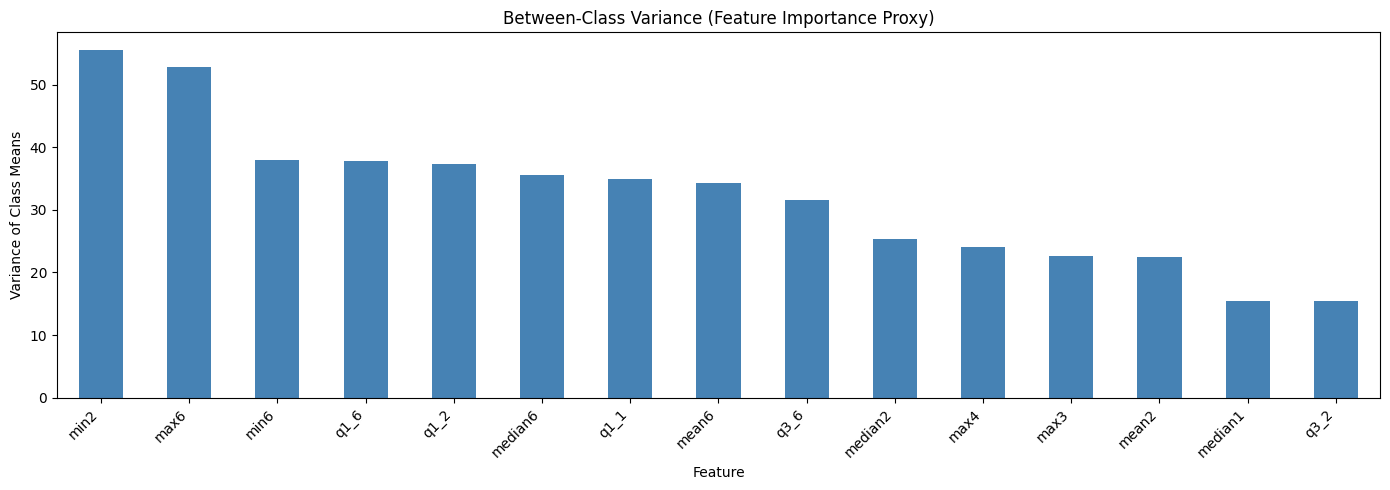

In [6]:
# Bar chart of feature importance
fig, ax = plt.subplots(figsize=(14, 5))
between_var.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Between-Class Variance (Feature Importance Proxy)')
ax.set_xlabel('Feature')
ax.set_ylabel('Variance of Class Means')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Question 2: ISLR Exercise 3.7.4

#### (a) 
**The cubic regression will have a lower (or equal) training RSS than the linear regression.**

Assuming both the linear and cubic models are fit using least squares, the cubic regression will have a training RSS less than or equal to that of the linear regression. This is because cubic polynomial is a more flexible model than a simple linear model. By adding the terms X² and X³, the cubic model has more parameters and can therefore always achieve a training RSS at least as small as the linear model.

#### (b) 
**We would expect the linear model to have a lower test RSS.**

When the true relationship is linear, the linear model is the correct model. The cubic model, while more flexible, is overfitting the training data. It captures noise rather than the true signal. On unseen test data, the extra flexibility of the cubic model leads to higher variance in predictions without a compensating reduction in bias. Therefore, by the bias-variance tradeoff, the linear model is expected to generalize better, resulting in lower test RSS. That said, the exact difference depends on the noise level and sample size, so in borderline cases the difference may be small.

#### (c) 

**The cubic regression will have a lower (or equal) training RSS than the linear regression.**

The same argument as in (a) applies here, regardless of the true functional form. The cubic model is more flexible than the linear model. It subsumes the linear model as a special case. Therefore, OLS fitting over a larger hypothesis class can only produce a training RSS that is less than or equal to that of the linear model. The non-linearity of the true relationship doesn't change this fact about training RSS.

#### (d) 
**There is not enough information to tell which test RSS will be lower.**

This depends on how non-linear the true relationship is:
- If the true relationship is slightly non-linear , the linear model may still generalize well, and its lower variance might outweigh its small bias, giving it better test RSS.
- If the true relationship is strongly non-linear, the cubic model will capture the curvature better, reducing bias substantially, and may yield lower test RSS despite higher variance.

Without knowing the degree of non-linearity, we cannot determine which model wins on test data. 